Imports firsthere

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

Loading the processed dataset

In [2]:
df = pd.read_csv("../data/processed/processed_returns.csv")

df.head()

,order_id,product_id,price,rating,return_status,price_bucket,low_rating_flag,product_order_count
0,O0001,P909,141.90,3,0,Low,0,2
1,O0002,P778,232.72,3,0,Medium,0,2
2,O0003,P508,496.90,3,0,High,0,1
3,O0004,P763,138.81,3,0,Low,0,3
4,O0005,P255,453.40,1,1,High,1,4


encode price bucket 

In [4]:
df = pd.get_dummies(
    df,
    columns=["price_bucket"],
    drop_first=True
)

In [5]:
df.columns

Index(['order_id', 'product_id', 'price', 'rating', 'return_status',
       'low_rating_flag', 'product_order_count', 'price_bucket_Low',
       'price_bucket_Medium'],
      dtype='object')

selecting featuress

In [10]:
features = [
    "price",
    "rating",
    "low_rating_flag",
    "product_order_count",
    "price_bucket_Low",
    "price_bucket_Medium"
]

Target will be

In [11]:
target = "return_status"

Train Test Split

In [12]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print(X.shape)
print(y.shape)

print(y.value_counts(normalize=True))

(1500, 6)
(1500,)
return_status
0    0.729333
1    0.270667
Name: proportion, dtype: float64


### Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:, 1]

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("ROC AUC  :", round(roc_auc_score(y_true, y_prob), 4))

In [26]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)


Logistic Regression
----------------------------------------
Accuracy : 0.7133
Precision: 0.451
Recall   : 0.284
F1 Score : 0.3485
ROC AUC  : 0.7111


Confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[191  28]
 [ 58  23]]


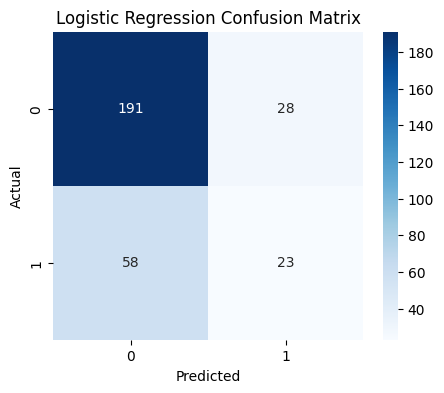

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../reports/figures/lr_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [29]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Random Forest
----------------------------------------
Accuracy : 0.63
Precision: 0.3026
Recall   : 0.284
F1 Score : 0.293
ROC AUC  : 0.5772


matrix

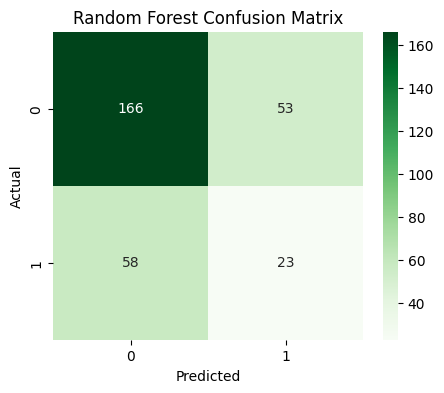

In [30]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../reports/figures/rf_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Classification Report

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       219
           1       0.30      0.28      0.29        81

    accuracy                           0.63       300
   macro avg       0.52      0.52      0.52       300
weighted avg       0.62      0.63      0.63       300



In [32]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.7133, 0.6300],
    "Precision": [0.4510, 0.3026],
    "Recall": [0.2840, 0.2840],
    "F1": [0.3485, 0.2930],
    "ROC_AUC": [0.7111, 0.5772]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7133,0.4510,0.284,0.3485,0.7111
1,Random Forest,0.6300,0.3026,0.284,0.2930,0.5772


# XG Booost

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [35]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [36]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)


XGBoost
----------------------------------------
Accuracy : 0.6967
Precision: 0.3958
Recall   : 0.2346
F1 Score : 0.2946
ROC AUC  : 0.6482


Matrix

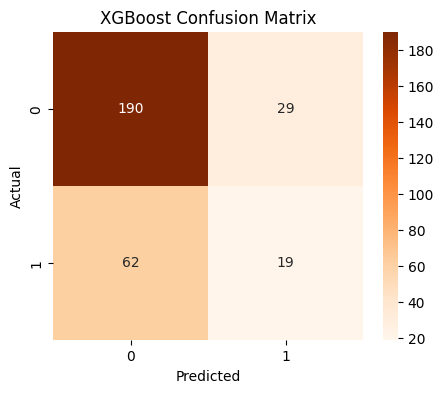

In [37]:
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../reports/figures/xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Hyperparameter Tuning

since we need hyperparameter tuning therefore we improve Logistic Regression.

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [39]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [40]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1, 'solver': 'liblinear'}
0.7236747252747253


In [41]:
best_lr = grid.best_estimator_

best_pred = best_lr.predict(X_test)

best_prob = best_lr.predict_proba(X_test)[:,1]

lets evaluate the tuned model too

In [42]:
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    best_pred,
    best_prob
)


Tuned Logistic Regression
----------------------------------------
Accuracy : 0.7233
Precision: 0.4783
Recall   : 0.2716
F1 Score : 0.3465
ROC AUC  : 0.7033


In [43]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lr.coef_[0]
})

feature_importance["Abs_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = (
    feature_importance
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
)

feature_importance

,Feature,Coefficient,Abs_Coefficient
4,price_bucket_Low,-0.535207,0.535207
5,price_bucket_Medium,-0.494629,0.494629
2,low_rating_flag,0.404487,0.404487
1,rating,-0.352161,0.352161
3,product_order_count,-0.015524,0.015524
0,price,0.001837,0.001837


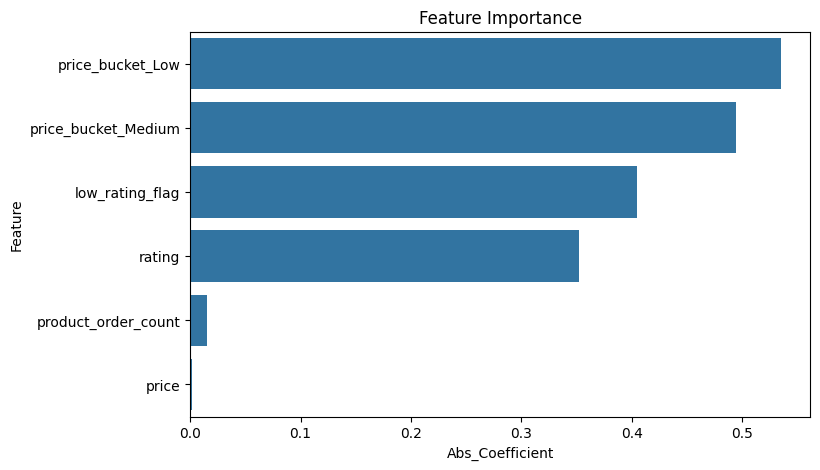

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Comparison and Selection

Three machine learning models were trained and evaluated for return prediction:

 Logistic Regression

 Random Forest
 
 XGBoost

### Final Model Selection

Tuned Logistic Regression was selected as the final model because it provided the best balance between predictive performance, interpretability, and deployment simplicity.


# Risk Scores

using best lr (Linear Regression)

In [46]:
df["risk_score"] = best_lr.predict_proba(X)[:, 1]

In [47]:
df[["risk_score"]].head()

,risk_score
0,0.154051
1,0.183061
2,0.377483
3,0.151308
4,0.618238


Risk Categories

In [48]:
df["risk_category"] = pd.cut(
    df["risk_score"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [49]:
df["risk_category"].value_counts()

risk_category
Low       891
Medium    550
High       59
Name: count, dtype: int64

High-Risk Orders Report

In [51]:
high_risk_orders = df[
    df["risk_category"] == "High"
]

high_risk_orders.head()

,order_id,product_id,price,rating,return_status,low_rating_flag,product_order_count,price_bucket_Low,price_bucket_Medium,risk_score,risk_category
4,O0005,P255,453.40,1,1,1,4,False,False,0.618238,High
13,O0014,P140,437.54,1,1,1,3,False,False,0.615020,High
37,O0038,P750,474.43,1,0,1,3,False,False,0.630937,High
81,O0082,P189,401.13,1,1,1,2,False,False,0.602788,High
224,O0225,P398,475.47,1,1,1,4,False,False,0.627761,High


In [52]:
high_risk_orders.to_csv(
    "../reports/High_Risk_Orders.csv",
    index=False
)

# Final Dataset

In [53]:
df.to_csv(
    "../data/processed/final_scored_dataset.csv",
    index=False
)

# Saving the Model

In [55]:
import joblib

joblib.dump(
    best_lr,
    "../models/return_prediction_model.pkl"
)

['../models/return_prediction_model.pkl']

saving the feature list also

In [56]:
joblib.dump(
    features,
    "../models/model_features.pkl"
)

['../models/model_features.pkl']

Exporting comparison tabnle

In [57]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

## Risk Scoring System

The final model was used to calculate a probability score representing the likelihood of product return.

### Risk Categories

 Low Risk: Probability below 30%

 Medium Risk: Probability between 30% and 60%
 
 High Risk: Probability above 60%

This risk classification can help businesses identify potentially problematic orders and take preventive actions before returns occur.
